# Hierarchical Clustering


This notebook groups customers with hierarchical clustering (Ward linkage),
using the cleaned data from cleaning.ipynb. We test different numbers of
clusters, pick the best one with the silhouette score, and interpret the result.

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CLEANED_DATA_PATH = "cleaned_marketing_campaign.csv"

df = pd.read_csv(CLEANED_DATA_PATH, parse_dates=["Dt_Customer"])
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Total_Purchases,Total_Campaigns_Accepted,Age_Group
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,55,0,1617,25,1,50-59
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,60,2,27,6,0,50-59
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,48,0,776,21,0,40-49
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,30,1,53,8,0,Under 30
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,33,1,422,19,0,30-39


## Feature prep

In [3]:
df["Total_Spending"] = df[[
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
]].sum(axis=1)

df["Total_Purchases"] = df[[
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
]].sum(axis=1)

features = ["Income", "Age", "Total_Spending", "Total_Purchases", "Recency", "Total_Children"]
X = df[features]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
import time
start = time.time()
sil_scores = {}
for k in range(2, 10):
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hc.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

print("Silhouette scores by k:", {k: round(v, 3) for k, v in sil_scores.items()})
best_k = max(sil_scores, key=sil_scores.get)
print(f"Best k: {best_k}")
print(f"Runtime: {time.time() - start:.2f} seconds")

Silhouette scores by k: {2: 0.29, 3: 0.229, 4: 0.179, 5: 0.188, 6: 0.168, 7: 0.165, 8: 0.162, 9: 0.163}
Best k: 2
Runtime: 2.73 seconds


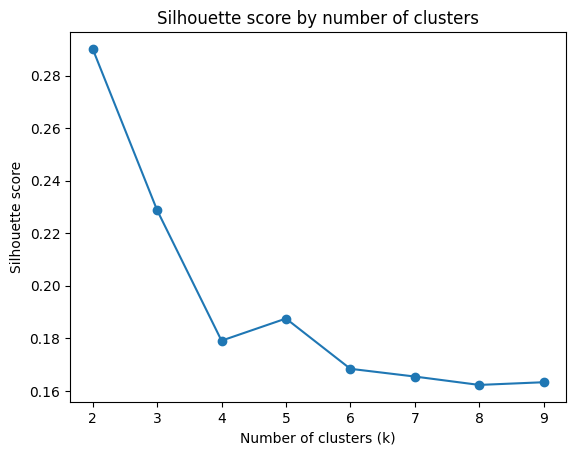

In [13]:
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score by number of clusters")
plt.show()

In [6]:
hc_final = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df["HC_Cluster"] = hc_final.fit_predict(X_scaled)

print(f"Final silhouette score: {silhouette_score(X_scaled, df['HC_Cluster']):.3f}")
print(df["HC_Cluster"].value_counts().sort_index())

Final silhouette score: 0.290
HC_Cluster
0    1026
1    1199
Name: count, dtype: int64


In [7]:
linkage_matrix = linkage(X_scaled, method="ward")

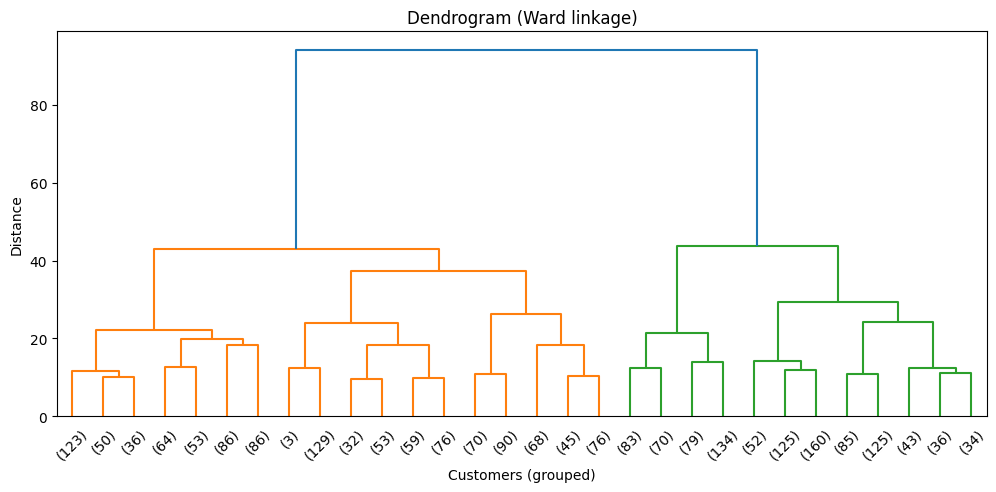

In [14]:
plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30)
plt.title("Dendrogram (Ward linkage)")
plt.xlabel("Customers (grouped)")
plt.ylabel("Distance")
plt.show()

The two branches at the top of the dendrogram merge at a much larger distance
than any earlier merge. This means the data naturally splits into two well
separated groups, which agrees with the silhouette result (best k = 2).

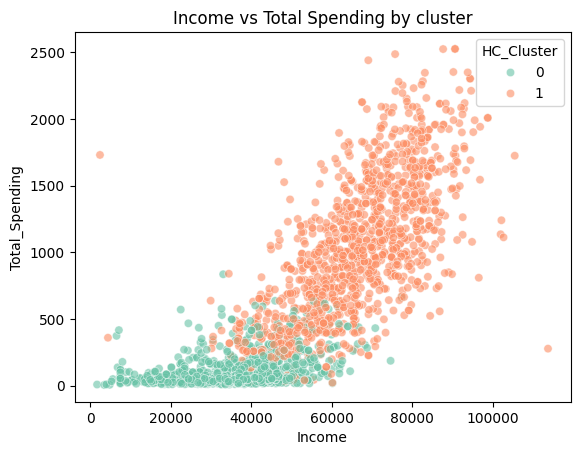

,Income,Age,Total_Spending,Total_Purchases,Recency,Total_Children,Size
HC_Cluster,,,,,,,
0,34464.5,41.9,109.4,8.3,51.5,1.3,1026
1,66322.2,46.2,1030.4,20.5,47.2,0.7,1199


In [15]:
sns.scatterplot(data=df, x="Income", y="Total_Spending", hue="HC_Cluster", palette="Set2", alpha=0.6)
plt.title("Income vs Total Spending by cluster")
plt.show()

profile = df.groupby("HC_Cluster")[features].mean().round(1)
profile["Size"] = df["HC_Cluster"].value_counts().sort_index()
profile

## Interpretation and reflection

The silhouette score showed that the best number of clusters was **k = 2**, with a score of **0.290**. The dendrogram also suggested that using two clusters was the best option, so both methods agreed on the same result.

**Cluster 1** contains the higher-value customers. There are **1,199 customers** in this group with an average income of around **66,300**. They spend much more overall, with average spending of about **1,030**, make around **20 purchases**, and usually have fewer children at home, with an average of **0.7**.

**Cluster 0** contains the more budget-conscious customers. This group has **1,026 customers** with an average income of around **34,500**. Their average spending is only about **109**, they make around **8 purchases**, and they tend to have more children at home, with an average of **1.3**.

K-Means produced almost the same two groups and had a slightly higher silhouette score of **0.306**. Since both methods found very similar customer segments, it gives more confidence that these clusters are meaningful.

DBSCAN did not work very well on this dataset because it created one large cluster and only a few small ones. Because of this, Hierarchical Clustering and K-Means were clearly better choices for this data.

The hierarchical clustering analysis for **k = 2 to 9** took about **3 seconds** to run. Even though hierarchical clustering can be slower than K-Means on larger datasets, the dataset only had **2,225 customers**, so the running time was not a problem.

In a real business situation, the company could use these results to create different marketing strategies. The higher-value customers could be targeted with loyalty rewards and premium offers, while the budget customers could receive discounts and family-focused promotions.
